In [1]:
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

# 데이터 로드
wine = load_wine()
X_train, X_test, y_train, y_test = train_test_split(
    wine.data, wine.target, random_state=42
)

# 기본 결정트리
dt = DecisionTreeClassifier(random_state=42)
scores = cross_validate(dt, X_train, y_train, cv=10, return_train_score=True)
print("기본 평균 정확도:", scores['test_score'].mean())


기본 평균 정확도: 0.9241758241758242


In [2]:
# 탐색할 파라미터 그리드 설정
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 6, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV로 교차검증 수행
dt = DecisionTreeClassifier(random_state=42)
gs = GridSearchCV(dt, param_grid, cv=10, n_jobs=-1)
gs.fit(X_train, y_train)

print("최적 하이퍼파라미터:", gs.best_params_)
print("최고 평균 교차검증 점수:", gs.best_score_)


최적 하이퍼파라미터: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}
최고 평균 교차검증 점수: 0.9461538461538461


In [3]:
best_dt = gs.best_estimator_
test_score = best_dt.score(X_test, y_test)
print("테스트 세트 정확도:", test_score)


테스트 세트 정확도: 0.8888888888888888


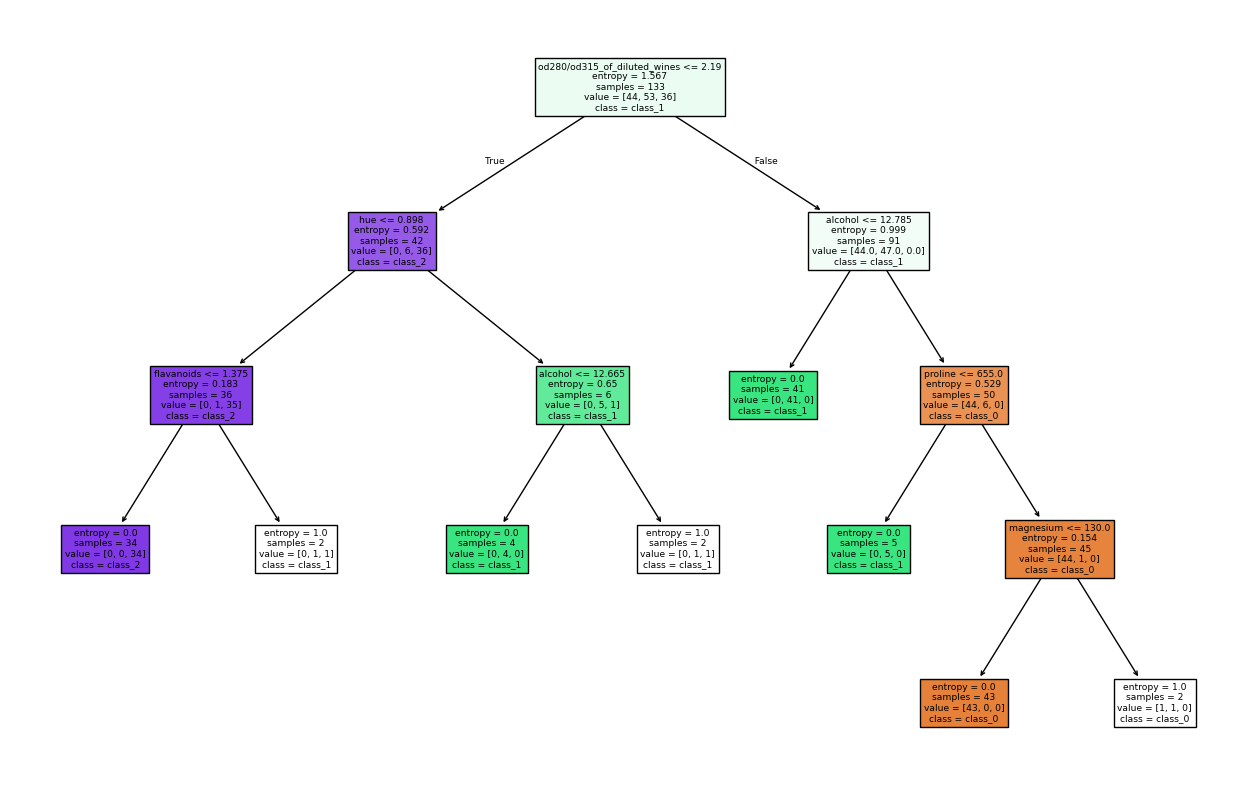

In [4]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))
plot_tree(best_dt, filled=True, feature_names=wine.feature_names, class_names=wine.target_names)
plt.show()
